In [2]:

# 1. Setup & auto path correction
# ==========================
import os

# Move up one level if running from notebooks/
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("📁 Current working directory:", os.getcwd())

# Create necessary directories
for d in ["data/processed", "models"]:
    os.makedirs(d, exist_ok=True)

# Configuration
RAW_DATA_DIR = "data/raw"          # will find nested s1/... folders automatically
PROCESSED_DIR = "data/processed"
MODEL_DIR = "models"
IMAGE_SIZE = (256, 256)
CLIP_MIN, CLIP_MAX = -50.0, 15.0
DTYPE_ACCUM = float

📁 Current working directory: /Users/vainavilad/flood-mumbai


In [3]:
# ==========================
# 2. Imports & helper functions
# ==========================
import numpy as np, json, rasterio
from rasterio.enums import Resampling
from tqdm import tqdm
import albumentations as A

def load_raster(path):
    try:
        with rasterio.open(path) as src:
            img = src.read(1, out_shape=(src.height, src.width), resampling=Resampling.bilinear)
        return img.astype(np.float32)
    except Exception as e:
        print("⚠️ Error loading:", path, e)
        return None

def get_transform():
    return A.Compose([
        A.Resize(*IMAGE_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ])

def preprocess_sample(vv_path, vh_path, mask_path, transform, gmean, gstd):
    vv, vh, mask = load_raster(vv_path), load_raster(vh_path), load_raster(mask_path)
    if vv is None or vh is None or mask is None: return None, None
    mask = (mask > 0).astype(np.uint8)
    img = np.stack([vv, vh], -1)
    img = np.clip(img, CLIP_MIN, CLIP_MAX)
    aug = transform(image=img, mask=mask)
    arr = aug["image"].astype(np.float32)
    for c in range(2):
        arr[..., c] = (arr[..., c] - gmean[c]) / (gstd[c] + 1e-8)
    return arr, aug["mask"].astype(np.uint8)

In [4]:
# ==========================
# 3. Process dataset and save mean/std (nested-folder compatible)
# ==========================
def process_dataset():
    transform = get_transform()
    valid_dirs, samples = [], []

    for root, _, files in os.walk(RAW_DATA_DIR):
        if all(name in files for name in ["VV.tif", "VH.tif", "LabelWater.tif"]):
            vv, vh = load_raster(os.path.join(root, "VV.tif")), load_raster(os.path.join(root, "VH.tif"))
            if vv is not None and vh is not None:
                img = np.stack([vv, vh], -1)
                img = np.clip(img, CLIP_MIN, CLIP_MAX)
                aug = transform(image=img)["image"].astype(np.float32)
                samples.append(aug)
                valid_dirs.append(root)

    if not samples:
        raise RuntimeError(f"No valid samples found under {RAW_DATA_DIR}. "
                           "Ensure .tif files are inside nested s1/... folders.")

    vv_all = np.concatenate([s[...,0].astype(DTYPE_ACCUM).ravel() for s in samples])
    vh_all = np.concatenate([s[...,1].astype(DTYPE_ACCUM).ravel() for s in samples])
    gmean = [float(np.mean(vv_all)), float(np.mean(vh_all))]
    gstd = [float(np.std(vv_all)), float(np.std(vh_all))]
    print("📊 Global mean/std:", gmean, gstd)

    X, y = [], []
    for root in tqdm(valid_dirs, desc="Processing"):
        vv, vh, mask = [os.path.join(root, f) for f in ("VV.tif", "VH.tif", "LabelWater.tif")]
        img, msk = preprocess_sample(vv, vh, mask, transform, gmean, gstd)
        if img is not None and msk is not None:
            X.append(img)
            y.append(msk)

    X, y = np.asarray(X, np.float32), np.asarray(y, np.uint8)
    np.save(os.path.join(PROCESSED_DIR, "images.npy"), X)
    np.save(os.path.join(PROCESSED_DIR, "masks.npy"), y)
    with open(os.path.join(MODEL_DIR, "global_stats.json"), "w") as f:
        json.dump({"mean": gmean, "std": gstd}, f, indent=2)
    print("✅ Saved processed data & global_stats.json")
    return X, y

X, y = process_dataset()

📊 Global mean/std: [-11.281756708657605, -18.101943310824954] [4.945670508896775, 5.675061883943232]


Processing: 100%|████████████████████████████| 900/900 [00:08<00:00, 108.77it/s]


✅ Saved processed data & global_stats.json


Images: (900, 256, 256, 2) Masks: (900, 256, 256) Mask values: [0 1]


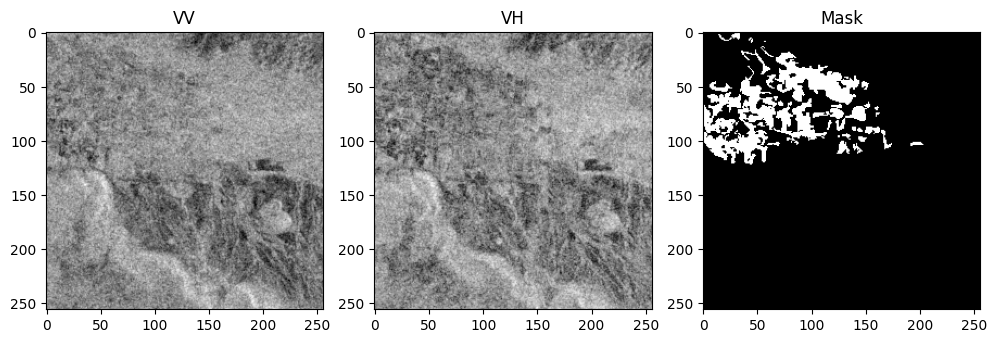

In [5]:
# ==========================
# 4. Quick visual check
# ==========================
import matplotlib.pyplot as plt
print("Images:", X.shape, "Masks:", y.shape, "Mask values:", np.unique(y))
i = 0
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(X[i,:,:,0], cmap='gray'); plt.title("VV")
plt.subplot(1,3,2); plt.imshow(X[i,:,:,1], cmap='gray'); plt.title("VH")
plt.subplot(1,3,3); plt.imshow(y[i], cmap='gray'); plt.title("Mask")
plt.tight_layout(); plt.show()

In [7]:
# ==========================
# 5. DeepLabV3+ (Mac-Air M4/M2 – FIXED & FAST)
# ==========================
import os
import tensorflow as tf

# Enable Metal GPU + mixed precision
os.environ["TF_METAL_DEVICE"] = "1"
tf.keras.mixed_precision.set_global_policy('mixed_float16')

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50

def aspp_block(x, filters=128):
    """ASPP with smaller rates for small feature maps"""
    shape = x.shape
    b0 = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x)
    b0 = layers.BatchNormalization()(b0); b0 = layers.Activation('relu')(b0)

    rates = (2, 4, 6)  # smaller due to 16×16 input
    b1 = layers.SeparableConv2D(filters, 3, padding='same', dilation_rate=rates[0], use_bias=False)(x)
    b1 = layers.BatchNormalization()(b1); b1 = layers.Activation('relu')(b1)

    b2 = layers.SeparableConv2D(filters, 3, padding='same', dilation_rate=rates[1], use_bias=False)(x)
    b2 = layers.BatchNormalization()(b2); b2 = layers.Activation('relu')(b2)

    b3 = layers.SeparableConv2D(filters, 3, padding='same', dilation_rate=rates[2], use_bias=False)(x)
    b3 = layers.BatchNormalization()(b3); b3 = layers.Activation('relu')(b3)

    b4 = layers.GlobalAveragePooling2D()(x)
    b4 = layers.Reshape((1,1,shape[-1]))(b4)
    b4 = layers.Conv2D(filters, 1, use_bias=False)(b4)
    b4 = layers.BatchNormalization()(b4); b4 = layers.Activation('relu')(b4)
    b4 = layers.UpSampling2D(size=(shape[1], shape[2]), interpolation='bilinear')(b4)

    out = layers.Concatenate()([b0, b1, b2, b3, b4])
    out = layers.Conv2D(filters, 1, use_bias=False)(out)
    out = layers.BatchNormalization()(out); out = layers.Activation('relu')(out)
    return out


def deeplabv3_plus_mac(input_shape=(256,256,2), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # Repeat channel to 3 for ResNet
    x = layers.Concatenate()([inputs, inputs[..., 1:2]])  # [B,256,256,3]

    # Frozen ResNet50 backbone
    backbone = ResNet50(weights='imagenet', include_top=False, input_tensor=x)
    backbone.trainable = False

    # Correct layer names:
    low_level = backbone.get_layer('conv2_block3_out').output   # 64×64 × 256
    high_level = backbone.get_layer('conv4_block6_out').output  # 16×16 × 1024

    # ASPP on high-level (16×16)
    x = aspp_block(high_level, filters=128)  # → 16×16 × 128

    # Upsample to 64×64 to match low-level
    x = layers.UpSampling2D(size=(4, 4), interpolation='bilinear')(x)  # 16→64

    # Prepare low-level (reduce channels)
    low_level = layers.Conv2D(48, 1, use_bias=False)(low_level)
    low_level = layers.BatchNormalization()(low_level)
    low_level = layers.Activation('relu')(low_level)

    # NOW both are 64×64
    x = layers.Concatenate()([x, low_level])  # [B, 64, 64, 176]

    # Decoder
    x = layers.SeparableConv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.SeparableConv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)

    # Final upsample to 256×256
    x = layers.UpSampling2D(size=(4, 4), interpolation='bilinear')(x)  # 64→256

    # Output in float32
    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid', dtype='float32')(x)

    return Model(inputs, outputs, name='DeepLabV3Plus_MacAir')


# -----------------------------------------------------------------
# Metrics
# -----------------------------------------------------------------
def dice_coefficient(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * inter + 1.) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.)

def iou_metric(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.round(tf.reshape(tf.cast(y_pred, tf.float32), [-1]))
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - inter
    return inter / (union + 1e-7)


# Build & compile
model = deeplabv3_plus_mac()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coefficient, iou_metric]
)

model.summary()

Model: "DeepLabV3Plus_MacAir"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 256, 256, 2)]        0         []                            
                                                                                                  
 tf.__operators__.getitem_1  (None, 256, 256, 1)          0         ['input_2[0][0]']             
  (SlicingOpLambda)                                                                               
                                                                                                  
 concatenate_3 (Concatenate  (None, 256, 256, 3)          0         ['input_2[0][0]',             
 )                                                                   'tf.__operators__.getitem_1[0
                                                                    ][0]']     

Original X shape: (900, 256, 256, 2) float32
Original y shape: (900, 256, 256, 1) float32
Fixed y shape: (900, 256, 256, 1) float32
Flood ratios: (900,), min=0.000, max=1.000
Labels: (900,), dtype=int32
Label distribution: [370 258 124 148]
Train: 720, Val: 180
Epoch 1/30
180/180 [==============================] - 45s 250ms/step - loss: 0.2989 - accuracy: 0.8866 - dice_coefficient: 0.3175 - iou_metric: 0.2900 - val_loss: 0.4772 - val_accuracy: 0.8628 - val_dice_coefficient: 0.1898 - val_iou_metric: 5.5811e-05 - lr: 0.0010
Epoch 2/30
180/180 [==============================] - 46s 257ms/step - loss: 0.1899 - accuracy: 0.9333 - dice_coefficient: 0.4881 - iou_metric: 0.4883 - val_loss: 0.3214 - val_accuracy: 0.8688 - val_dice_coefficient: 0.1987 - val_iou_metric: 0.0284 - lr: 0.0010
Epoch 3/30
180/180 [==============================] - 49s 274ms/step - loss: 0.1755 - accuracy: 0.9398 - dice_coefficient: 0.5043 - iou_metric: 0.5069 - val_loss: 0.4657 - val_accuracy: 0.7802 - val_dice_coeffi

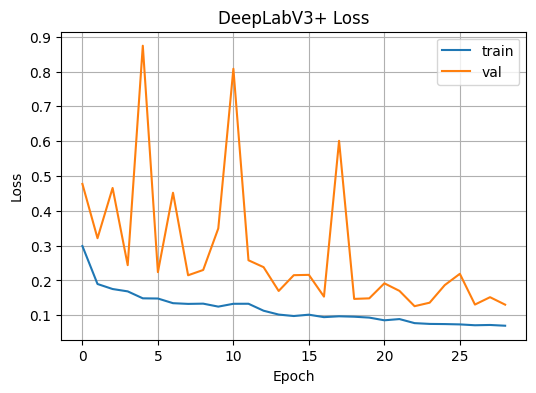

In [12]:
# ==========================
# 6. Train (Mac-Air) – FINAL FIXED VERSION
# ==========================
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# 1. Fix y shape: remove extra dims
# -------------------------------------------------
print("Original X shape:", X.shape, X.dtype)
print("Original y shape:", y.shape, y.dtype)

# Force y to be (N, 256, 256, 1) float32
while y.ndim > 4:
    y = y.squeeze(axis=-1)  # remove any trailing 1s
y = y.astype(np.float32)

print("Fixed y shape:", y.shape, y.dtype)

# -------------------------------------------------
# 2. Compute flood ratio per image → 1D
# -------------------------------------------------
flood_ratios = np.mean(y, axis=(1, 2, 3))  # → (N,)
flood_ratios = flood_ratios.ravel()       # ensure 1D
print(f"Flood ratios: {flood_ratios.shape}, min={flood_ratios.min():.3f}, max={flood_ratios.max():.3f}")

# -------------------------------------------------
# 3. Create 1D integer labels
# -------------------------------------------------
bins = [0.01, 0.1, 0.3]
labels = np.digitize(flood_ratios, bins)   # → (N,)
labels = labels.astype(np.int32)           # 1D int32

print(f"Labels: {labels.shape}, dtype={labels.dtype}")
print(f"Label distribution: {np.bincount(labels)}")  # NOW WORKS!

# -------------------------------------------------
# 4. Train/val split
# -------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}")

# -------------------------------------------------
# 5. Callbacks
# -------------------------------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

# -------------------------------------------------
# 6. TRAIN
# -------------------------------------------------
history = model.fit(
    X_train, y_train,
    batch_size=4,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

# -------------------------------------------------
# 7. Plot
# -------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('DeepLabV3+ Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True); plt.show()

In [14]:
# ==========================
# 7. Evaluate & save – FIXED FOR MAC AIR + TF BUG
# ==========================
import numpy as np
import os
import tensorflow as tf

# -------------------------------------------------
# 1. Evaluate on validation set
# -------------------------------------------------
val_pred = (model.predict(X_val, batch_size=4) > 0.5).astype(np.uint8)

dice_scores = [
    2 * np.sum(y_val[i] * val_pred[i]) /
    (np.sum(y_val[i]) + np.sum(val_pred[i]) + 1e-7)
    for i in range(len(y_val))
]
print(f"Mean Validation Dice: {np.mean(dice_scores):.4f}")

# -------------------------------------------------
# 2. Save model SAFELY (avoid custom metric bug)
# -------------------------------------------------
# Option A: Save as SavedModel (RECOMMENDED – always works)
savedmodel_path = os.path.join(MODEL_DIR, "deeplab_macair_flood_savedmodel")
model.save(savedmodel_path, include_optimizer=False)
print(f"Model saved as SavedModel → {savedmodel_path}")

# Option B: Save weights only (light & safe)
weights_path = os.path.join(MODEL_DIR, "deeplab_macair_flood_weights.h5")
model.save_weights(weights_path)
print(f"Weights saved → {weights_path}")

# -------------------------------------------------
# 3. (Optional) Save architecture separately
# -------------------------------------------------
arch_path = os.path.join(MODEL_DIR, "deeplab_macair_flood_architecture.json")
with open(arch_path, 'w') as f:
    f.write(model.to_json())
print(f"Architecture saved → {arch_path}")

45/45 [==============================] - 6s 137ms/step
Mean Validation Dice: 0.4035
INFO:tensorflow:Assets written to: models/deeplab_macair_flood_savedmodel/assets


INFO:tensorflow:Assets written to: models/deeplab_macair_flood_savedmodel/assets


Model saved as SavedModel → models/deeplab_macair_flood_savedmodel
Weights saved → models/deeplab_macair_flood_weights.h5
Architecture saved → models/deeplab_macair_flood_architecture.json


1/1 [==============================] - 0s 59ms/step


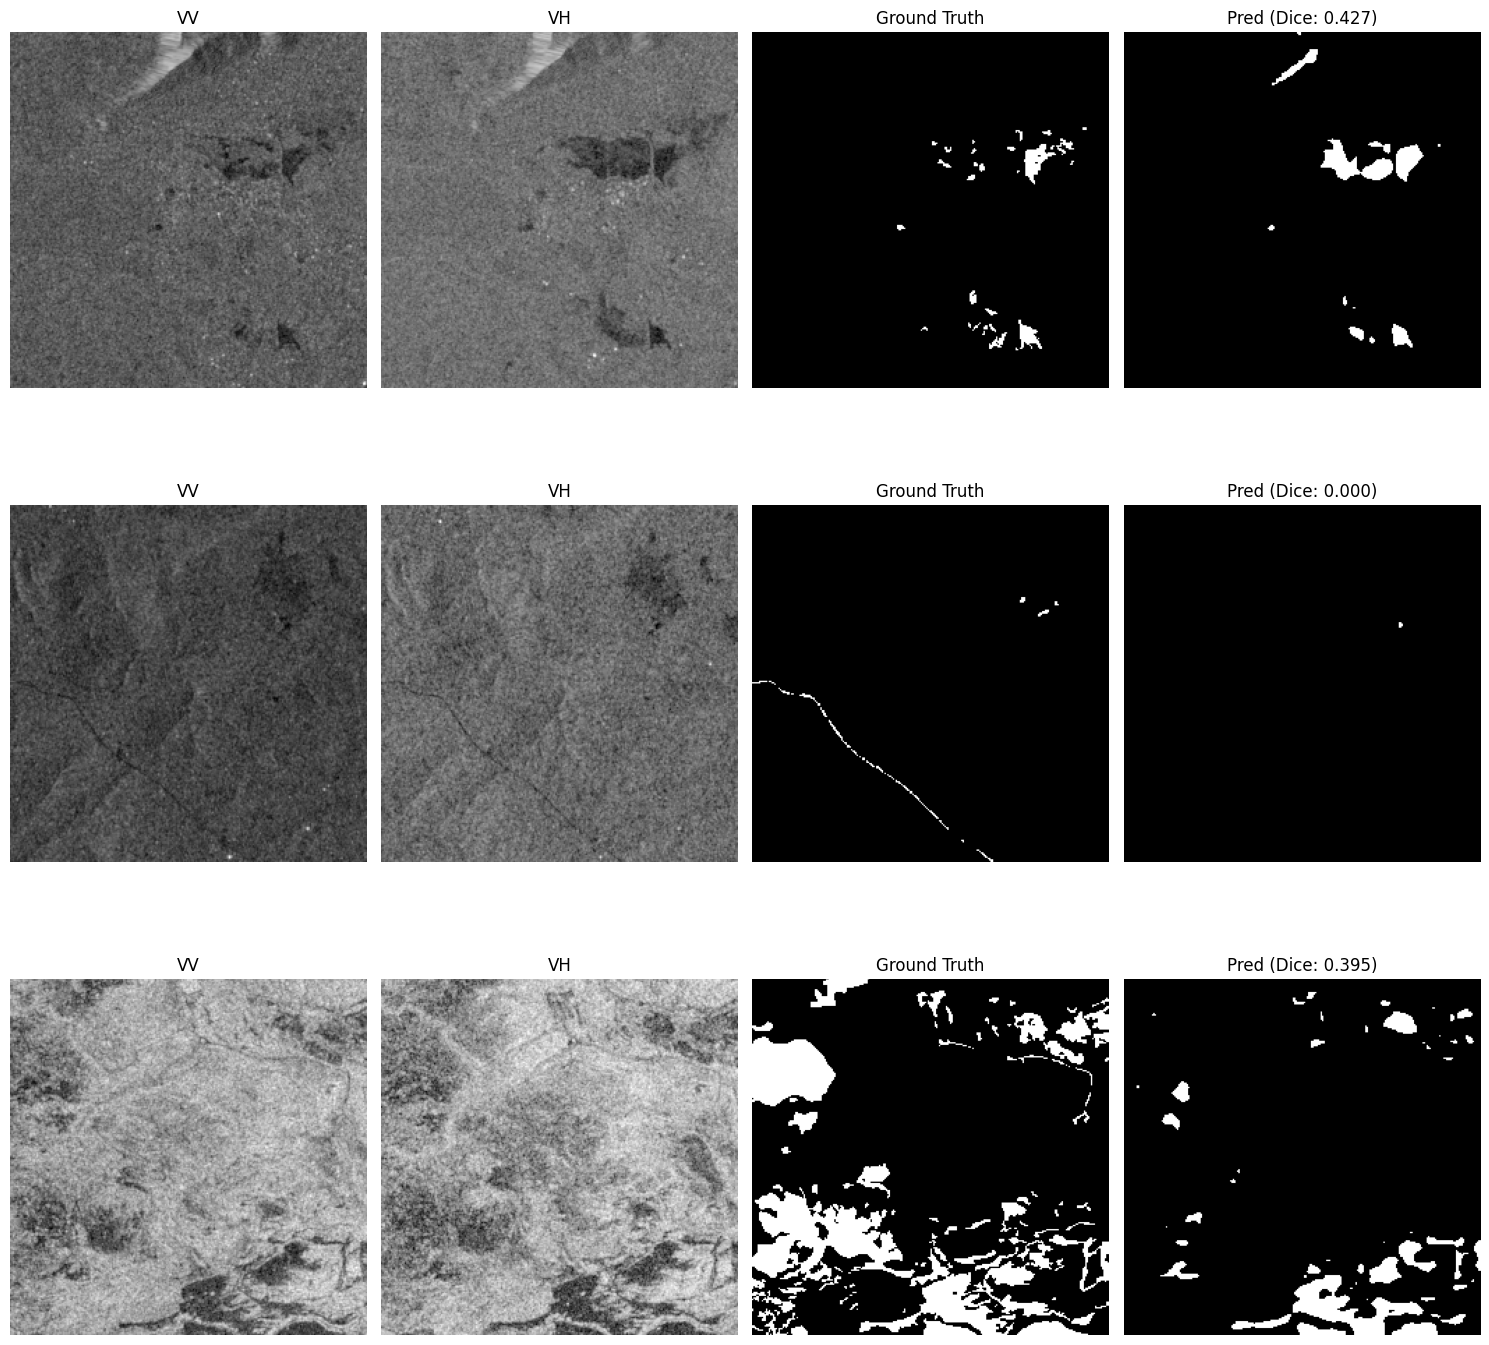

In [15]:
# ==========================
# 8. Visualize Results
# ==========================
import matplotlib.pyplot as plt
import random

n = 3
indices = random.sample(range(len(X_val)), n)

plt.figure(figsize=(15, 5*n))
for i, idx in enumerate(indices):
    pred = (model.predict(X_val[idx:idx+1]) > 0.5)[0, :, :, 0]

    plt.subplot(n, 4, 4*i+1)
    plt.imshow(X_val[idx, :, :, 0], cmap='gray')
    plt.title('VV'); plt.axis('off')

    plt.subplot(n, 4, 4*i+2)
    plt.imshow(X_val[idx, :, :, 1], cmap='gray')
    plt.title('VH'); plt.axis('off')

    plt.subplot(n, 4, 4*i+3)
    plt.imshow(y_val[idx, :, :, 0], cmap='gray')
    plt.title('Ground Truth'); plt.axis('off')

    plt.subplot(n, 4, 4*i+4)
    plt.imshow(pred, cmap='gray')
    plt.title(f'Pred (Dice: {dice_scores[idx]:.3f})'); plt.axis('off')

plt.tight_layout()
plt.show()

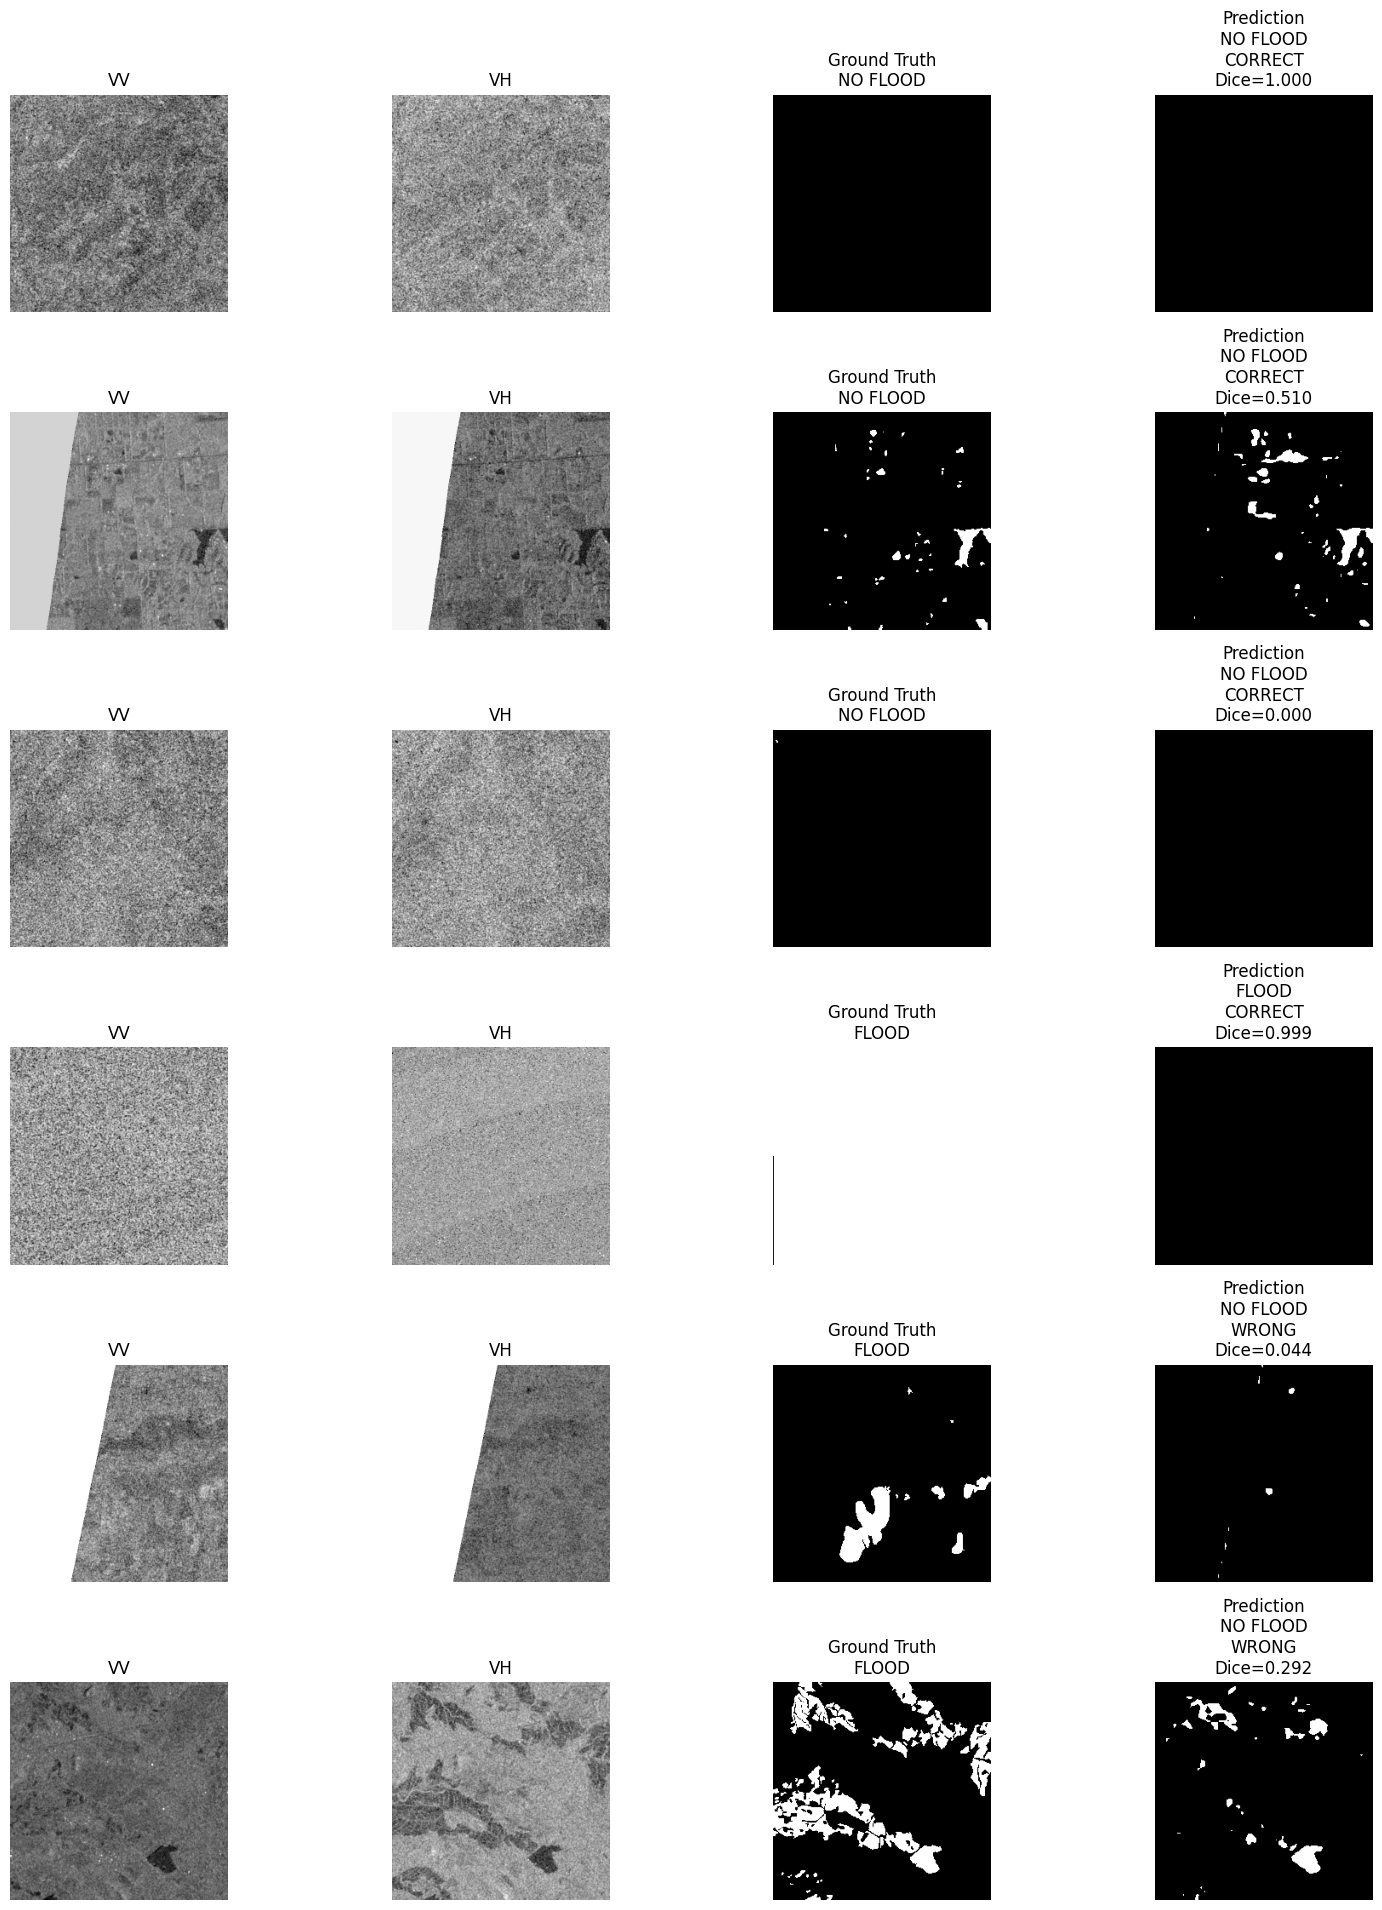

In [18]:
# ==========================
# 8. Visualise – GT & PRED: FLOOD / NO FLOOD + CORRECT/WRONG
# ==========================
import matplotlib.pyplot as plt
import numpy as np
import random

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
n_samples   = 6                                 # number of examples
flood_thr   = 0.05                              # % of pixels → "FLOOD"
random.seed(42)

# -------------------------------------------------
# Helper: label an image as FLOOD / NO FLOOD
# -------------------------------------------------
def get_flood_label(mask, threshold=flood_thr):
    ratio = np.mean(mask)
    return "FLOOD" if ratio >= threshold else "NO FLOOD"

def single_dice(gt, pred):
    inter = np.sum(gt * pred)
    return (2 * inter + 1e-7) / (np.sum(gt) + np.sum(pred) + 1e-7)

# -------------------------------------------------
# Pick random validation samples
# -------------------------------------------------
indices = random.sample(range(len(X_val)), n_samples)

plt.figure(figsize=(16, 3.2 * n_samples))

for i, idx in enumerate(indices):
    # ---- Input -------------------------------------------------
    vv = X_val[idx, :, :, 0]
    vh = X_val[idx, :, :, 1]

    # ---- Masks -------------------------------------------------
    gt   = y_val[idx, :, :, 0]                                      # (256,256)
    pred = (model.predict(X_val[idx:idx+1], verbose=0) > 0.5)[0, :, :, 0]

    # ---- Labels ------------------------------------------------
    gt_label     = get_flood_label(gt)
    pred_label   = get_flood_label(pred)
    is_correct   = "CORRECT" if gt_label == pred_label else "WRONG"
    dice         = single_dice(gt, pred)

    # ---- Plot --------------------------------------------------
    plt.subplot(n_samples, 4, 4*i + 1)
    plt.imshow(vv, cmap='gray')
    plt.title('VV')
    plt.axis('off')

    plt.subplot(n_samples, 4, 4*i + 2)
    plt.imshow(vh, cmap='gray')
    plt.title('VH')
    plt.axis('off')

    plt.subplot(n_samples, 4, 4*i + 3)
    plt.imshow(gt, cmap='gray')
    plt.title(f'Ground Truth\n{gt_label}')
    plt.axis('off')

    plt.subplot(n_samples, 4, 4*i + 4)
    plt.imshow(pred, cmap='gray')
    plt.title(f'Prediction\n{pred_label}\n{is_correct}\nDice={dice:.3f}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# ==========================
# SAVE COMPARISON DATA – FIXED & SELF-CONTAINED
# ==========================
import numpy as np
import os
from tensorflow.keras.models import load_model
import tensorflow as tf

# -------------------------------------------------
# 1. DEFINE CUSTOM METRICS (MUST BE SAME AS TRAINING)
# -------------------------------------------------
def dice_coefficient(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * inter + 1.) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.)

def iou_metric(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.round(tf.reshape(tf.cast(y_pred, tf.float32), [-1]))
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - inter
    return inter / (union + 1e-7)

# -------------------------------------------------
# 2. LOAD MODELS SAFELY (with error handling)
# -------------------------------------------------
MODEL_DIR = "./models"

# Load DeepLabV3+ (you already have this)
try:
    model_deeplab = load_model(
        os.path.join(MODEL_DIR, "deeplab_macair_flood_savedmodel"),
        custom_objects={'dice_coefficient': dice_coefficient, 'iou_metric': iou_metric},
        compile=False  # Skip compile to avoid metric issues
    )
    print("DeepLabV3+ loaded")
except Exception as e:
    print("DeepLabV3+ not found:", e)
    model_deeplab = None

# Load U-Net (you must have trained it earlier)
try:
    model_unet = load_model(
        os.path.join(MODEL_DIR, "unet_flood_savedmodel"),  # CHANGE PATH IF NEEDED
        custom_objects={'dice_coefficient': dice_coefficient, 'iou_metric': iou_metric},
        compile=False
    )
    print("U-Net loaded")
except Exception as e:
    print("U-Net not found:", e)
    model_unet = None

# -------------------------------------------------
# 3. CHECK IF MODELS EXIST
# -------------------------------------------------
if model_unet is None or model_deeplab is None:
    print("\nOne or both models missing!")
    print("Train and save U-Net first, or skip comparison.")
    print("Expected paths:")
    print("  models/unet_flood_savedmodel/")
    print("  models/deeplab_macair_flood_savedmodel/")
else:
    print("Both models ready for comparison!")

# -------------------------------------------------
# 4. PREDICT & SAVE (only if both models loaded)
# -------------------------------------------------
if model_unet and model_deeplab:
    print(f"Predicting on {len(X_val)} validation samples...")

    pred_unet = (model_unet.predict(X_val, batch_size=4, verbose=0) > 0.5).astype(np.uint8)
    pred_deeplab = (model_deeplab.predict(X_val, batch_size=4, verbose=0) > 0.5).astype(np.uint8)

    # Compute metrics
    def compute_metrics(y_true, y_pred):
        y_true_f = y_true.flatten()
        y_pred_f = y_pred.flatten()
        dice = 2 * np.sum(y_true_f * y_pred_f) / (np.sum(y_true_f) + np.sum(y_pred_f) + 1e-7)
        iou = np.sum(y_true_f * y_pred_f) / (np.sum(y_true_f) + np.sum(y_pred_f) - np.sum(y_true_f * y_pred_f) + 1e-7)
        acc = np.mean(y_true_f == y_pred_f)
        return {'dice': dice, 'iou': iou, 'accuracy': acc}

    metrics_unet = compute_metrics(y_val, pred_unet)
    metrics_deeplab = compute_metrics(y_val, pred_deeplab)

    # Save everything
    os.makedirs("./data/processed", exist_ok=True)
    np.save('./data/processed/pred_unet.npy', pred_unet)
    np.save('./data/processed/pred_deeplab.npy', pred_deeplab)
    np.save('./data/processed/metrics.npy', {'unet': metrics_unet, 'deeplab': metrics_deeplab})
    np.save('./data/processed/sample_indices.npy', np.arange(len(X_val)))

    print("Comparison data saved!")
    print("U-Net Dice:", metrics_unet['dice'])
    print("DeepLab Dice:", metrics_deeplab['dice'])

DeepLabV3+ not found: No file or directory found at ./models/deeplab_macair_flood_savedmodel
U-Net not found: No file or directory found at ./models/unet_flood_savedmodel

One or both models missing!
Train and save U-Net first, or skip comparison.
Expected paths:
  models/unet_flood_savedmodel/
  models/deeplab_macair_flood_savedmodel/
